# Introduction
---
This notebook is meant to give an overview on the functionality of the autoXPCS package

Each step of the analysis is described, so the data_loading can be exchanged to the desired beamline, while the rest of the analysis stays the same 

In [148]:
#clean this up at some point
%load_ext autoreload
%autoreload 2
import numpy as np 
from pathlib import Path

import pyFAI
import time
import json
import sys 
sys.path.append('../.')
from data_loading import p10 as data_loader # only need to exchange the beamline
from general import scans, masking
from processing import saxs, xpcs
from ploty import plotting
import xarray as xr
import dask
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import hdf5plugin

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [149]:
"""
Using system sheduler works better than Client
might be used in later more optimized version or might have to be used on cluster
# if code does not work further down the line restart kernel and skip this block
from dask.distributed import Client

client = Client()
"""

'\nUsing system sheduler works better than Client\nmight be used in later more optimized version or might have to be used on cluster\n# if code does not work further down the line restart kernel and skip this block\nfrom dask.distributed import Client\n\nclient = Client()\n'

# Input

In [187]:
dir_beamtime = Path('./data/')
sample_name = 'm036_hiAmylose_starch'
scan_number = 45
detector = 'e4m'
skip_frames_start = 200
skip_frames_end = None

filename_mask = dir_beamtime / 'preliminary_mask.npy'
#filename_poni = dir_beamtime / 'processed/SAXSdetector_2025_08_31.poni' # if you don't have a poni file yet, you can use function 'create_poni_from_batchinfoP10(filename_batchinfo, pixel_size_m)' instead

# define the q-partitions
q_centers = np.arange(0.15,0.9,0.05) * 1e9
q_widths = 0.05*np.ones(len(q_centers)) * 1e9

dir_results = Path('output/.')
dir_results.mkdir(parents=True, exist_ok=True)

# Processing

In [188]:
sample = scans.Sample(dir_beamtime=dir_beamtime, sample_name=sample_name)
mask = masking.Mask(filename_mask=filename_mask)
#experimental_parameters:dict[str:Any] = {}

In [189]:
################################################
### Load the raw data of the provided scan  ###
###############################################

# ScanSeries
time_start = time.time()
# create instances
scan_series = scans.ScanSeries(sample=sample,
                               detector=detector,
                               scan_number=scan_number,
                               skip_frames_start=skip_frames_start,
                               skip_frames_end=skip_frames_end,
                              )
scan_series.add_mask(mask=mask)

# load data
data_loader.load_data(scan_series, chunk_size='auto')
time_intermediate = time.time()
print(f'Took {time_intermediate - time_start:.3f} s for initialization and loading data.')

Took 0.004 s for initialization and loading data.


In [190]:
##################################
####Provide pyFAI configuration###
##################################

# load pyFAI configuration as poni file
data_loader.create_poni_file(scan_series)


#experimental_parameters.update(experimental_params_config)
#pyFAI_config.save(dir_results / 'pyfai_config.poni') # save pyFAI configuration as poni file
#experimental_parameters['pyFAI_config'] = 'pyfai_config.poni'

In [191]:
##################################################
### Process the detector image using the mask  ###
##################################################

#change this at some point

time_inter_start = time.time()
incoherent_img, incoherent_img_cor = masking.process_incoherent_image(data3D=scan_series.raw_data,
                                                                        #[scan_series.skip_frames_start:,:,:],
                                                                       mask=mask)
#summary_incoherent_img = proc_scans.save_incoherent_image_results(dir_results, incoherent_img, incoherent_img_cor)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating incoherent image.')

Took 0.011 s for calculating incoherent image.


In [192]:
################################
### Process SAXS information ###
################################

time_inter_start = time.time()
scan_series.calculate_saxs_mean()
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for total SAXS curve.')


time_inter_start = time.time()
scan_series.calculate_saxs_evo_each_frame()
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for frame resolved SAXS processing.')

time_inter_start = time.time()

scan_series.calculate_saxs_evo(precision_SAXS=600,
                                segments=10,
                              )

#summary_evo_SAXS = proc_scans.save_SAXS_results(dir_results, 'evolution_SAXS', evo_SAXS_Q, evo_SAXS_IofQ, evo_SAXS_errorIofQ)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for evolution of SAXS data.')

IndexError: The number of skipped frames exceeds the number of frames in the measurement, which is 150.

<xarray.Dataset> Size: 1MB
Dimensions:       (frames: 150, q: 600)
Coordinates:
    max_frame_nr  (frames) float64 1kB 1.0 2.0 3.0 4.0 ... 148.0 149.0 150.0
    max_exp_time  (frames) float32 600B 0.2 0.4 0.6 0.8 ... 29.4 29.6 29.8 30.0
  * q             (q) float64 5kB 1.019e+06 3.058e+06 ... 1.22e+09 1.222e+09
Dimensions without coordinates: frames
Data variables:
    IofQ          (frames, q) float64 720kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    IofQerror     (frames, q) float64 720kB 0.1697 0.09879 ... 0.1723 0.2963
Attributes:
    segments:            150
    frames_per_segment:  1


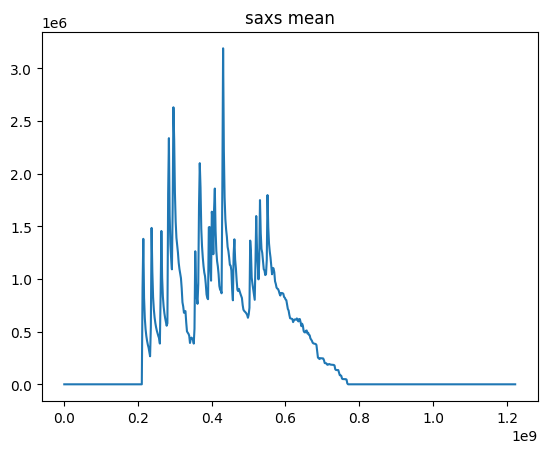

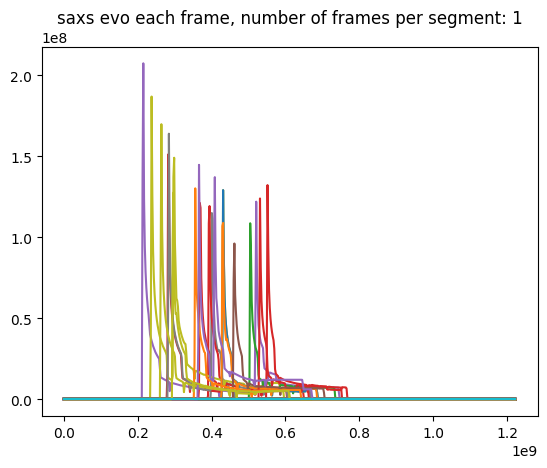

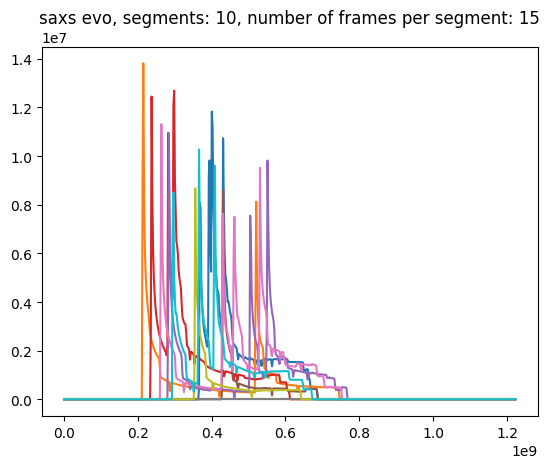

In [177]:
plt.figure()
plt.plot(scan_series.saxs_mean_results.q, scan_series.saxs_mean_results.IofQ)
plt.title('saxs mean')

plt.figure()
for i in range(scan_series.saxs_evo_results_each_frame.frames.shape[0]):
    plt.plot(scan_series.saxs_evo_results_each_frame.q,
             scan_series.saxs_evo_results_each_frame.IofQ.sel(frames=i))
    plt.title(f'saxs evo each frame, number of frames per segment: {scan_series.saxs_evo_results_each_frame.frames_per_segment}')
print(scan_series.saxs_evo_results_each_frame)   
plt.figure()
for i in range(scan_series.saxs_evo_results.frames.shape[0]):
    plt.plot(scan_series.saxs_evo_results.q,
             scan_series.saxs_evo_results.IofQ.sel(frames=i))
    plt.title(f'saxs evo, segments: {scan_series.saxs_evo_results.segments}, number of frames per segment: {scan_series.saxs_evo_results.frames_per_segment}')

Took 0.087 s for defining Q-partitions.
15
<xarray.DataArray 'q-ring masks' (y: 2167, x: 2070)> Size: 36MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2167, 2070))
Dimensions without coordinates: y, x


<function matplotlib.pyplot.show(close=None, block=None)>

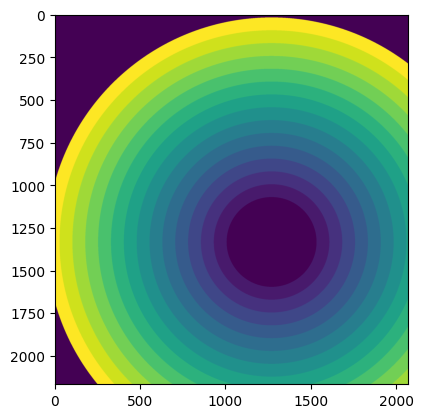

In [178]:
time_inter_start = time.time()
q_rings = masking.QRings(q_centers=q_centers,
                         q_widths=q_widths,
                         detector_shape=(mask.dim_y, mask.dim_x),
                         poni_info = scan_series.pyfai_config
                        )

scan_series.add_qrings(q_rings)
#print(scan_series.q_rings.mask_arrays)
"""
q_partitions = masking.QPartitions()
q_partitions.define_partitions(partition_arrays=q_rings.arrays, info=q_rings.info)
#asummary_partitions = proc_scans.save_Q_partitions(dir_results, q_partitions)
scan_series.input['q_partitions'] = summary_partitions
"""
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for defining Q-partitions.')
a = len(scan_series.q_rings.mask_arrays)
print(a)
plt.figure()

image = np.zeros((2167,2070))
for i in range(a):
    image = image+scan_series.q_rings.mask_arrays.sel(partitions=i)*i
print(scan_series.q_rings.mask_arrays.sel(partitions=i))
plt.imshow(image)
plt.show

In [179]:
################################
### Process XPCS information ###
################################

time_inter_start = time.time()
scan_series.calculate_ttcfs()
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating ttcfs.')
"""
time_inter_start = time.time()
g2_from_ttcs = scan_series.calculate_all_g2s(ttc_per_q_partition)
times_g2_from_ttcs_s = np.arange(g2_from_ttcs.shape[-1])*experimental_parameters['delay_time_s'] + experimental_parameters['delay_time_s']
summary_g2_from_ttc = proc_scans.save_results_g2(dir_results, 'g2_from_ttc', times_g2_from_ttcs_s, g2_from_ttcs)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating g2s from ttcfs.')

time_inter_start = time.time()
times_multitau, g2multitau_per_q_partition, g2errormultitau_per_q_partition = scan_series.calculate_g2s_multitau(q_partitions)
times_multitau = times_multitau*experimental_parameters['delay_time_s']
summary_g2_multitau = proc_scans.save_results_g2(dir_results, 'g2_multitau', times_multitau, g2multitau_per_q_partition)
time_inter_end = time.time()
print(f'Took {time_inter_end - time_inter_start:.3f} s for calculating g2s via multitau.')
"""

"""
# output
dict_summary = {}
dict_summary['input'] = scan_series.input
dict_summary['experimental_parameters'] = experimental_parameters
dict_summary['results_incoherent_image'] = summary_incoherent_img
dict_summary['results_SAXS'] = summary_SAXS
dict_summary['results_frame_resolved_SAXS'] = summary_frame_resolved_SAXS
dict_summary['results_evolution_SAXS'] = summary_evo_SAXS
dict_summary['results_ttc'] = summary_ttc
dict_summary['results_g2_from_ttc'] = summary_g2_from_ttc
dict_summary['results_g2_multitau'] = summary_g2_multitau
with open(dir_results / 'input_output_summary.json', "w") as f:
    json.dump(dict_summary, f, indent=4, default=proc_det.custom_encoder)


time_end = time.time()
print(f'Took {time_end - time_start:.3f} s for processing.')
"""

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
Took 69.383 s for calculating ttcfs.


'\n# output\ndict_summary = {}\ndict_summary[\'input\'] = scan_series.input\ndict_summary[\'experimental_parameters\'] = experimental_parameters\ndict_summary[\'results_incoherent_image\'] = summary_incoherent_img\ndict_summary[\'results_SAXS\'] = summary_SAXS\ndict_summary[\'results_frame_resolved_SAXS\'] = summary_frame_resolved_SAXS\ndict_summary[\'results_evolution_SAXS\'] = summary_evo_SAXS\ndict_summary[\'results_ttc\'] = summary_ttc\ndict_summary[\'results_g2_from_ttc\'] = summary_g2_from_ttc\ndict_summary[\'results_g2_multitau\'] = summary_g2_multitau\nwith open(dir_results / \'input_output_summary.json\', "w") as f:\n    json.dump(dict_summary, f, indent=4, default=proc_det.custom_encoder)\n\n\ntime_end = time.time()\nprint(f\'Took {time_end - time_start:.3f} s for processing.\')\n'

<xarray.Dataset> Size: 3MB
Dimensions:        (q: 15, frame1: 150, frame2: 150, q_widths: 15)
Coordinates:
  * q              (q) float64 120B 1.5e+08 2e+08 2.5e+08 ... 8e+08 8.5e+08
    t1             (frame1) float32 600B 0.0 0.2 0.4 0.6 ... 29.2 29.4 29.6 29.8
  * q_widths       (q_widths) float64 120B 5e+07 5e+07 5e+07 ... 5e+07 5e+07
Dimensions without coordinates: frame1, frame2
Data variables:
    ttcfs          (q, frame1, frame2) float64 3MB 1.45e+03 0.0 ... 3.073e+04
    pixel_in_ring  (q) float64 120B 9.572e+04 1.089e+05 ... 2.597e+05 2.459e+05


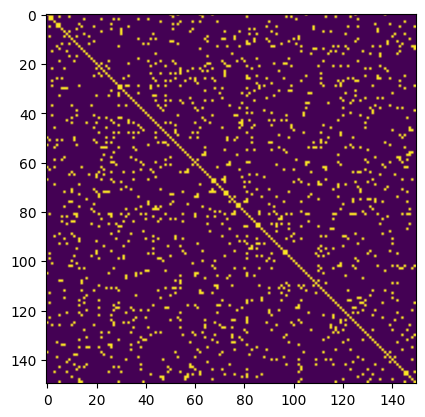

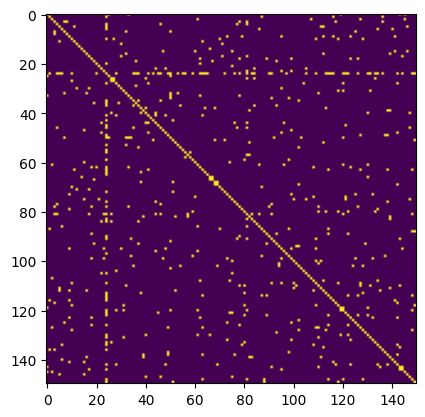

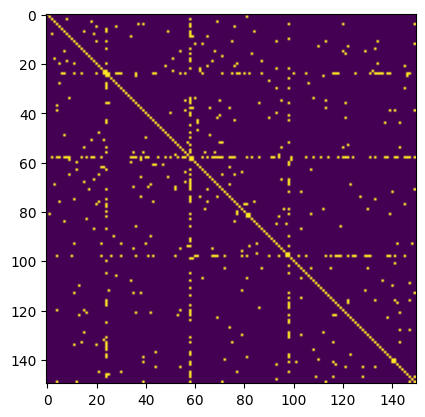

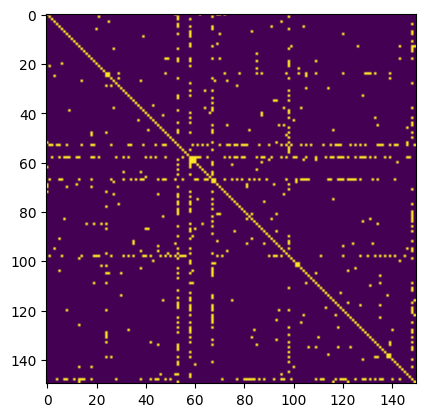

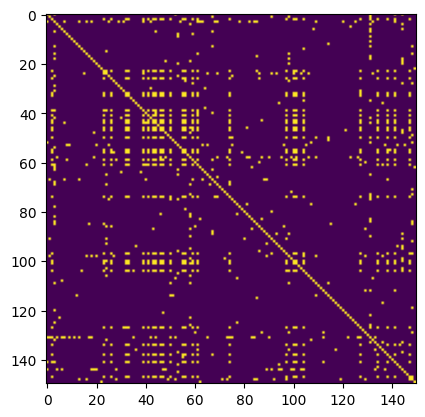

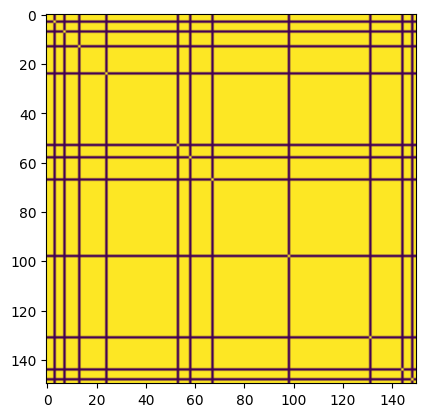

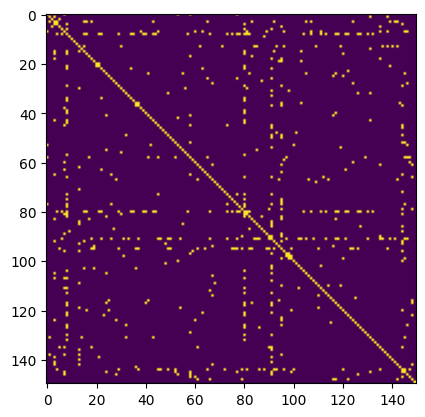

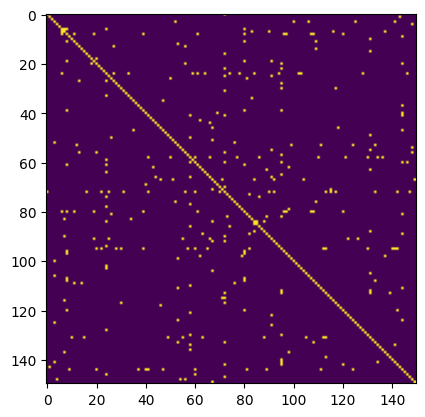

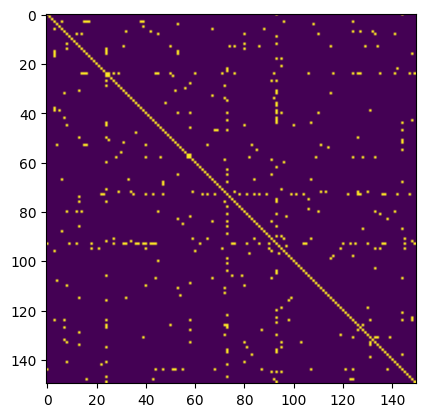

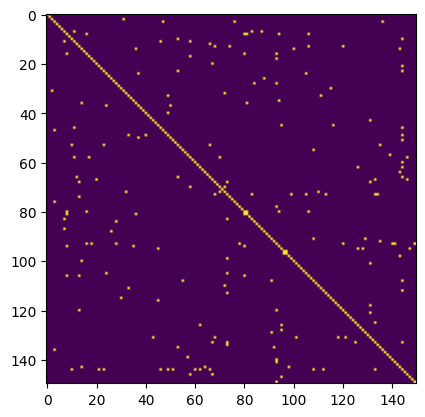

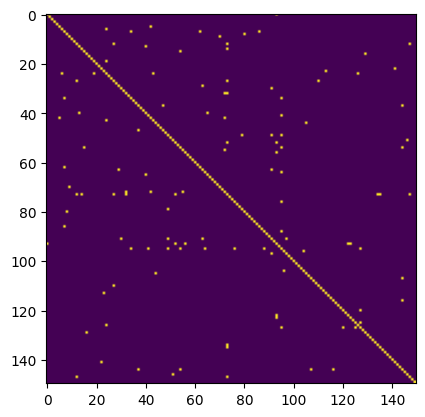

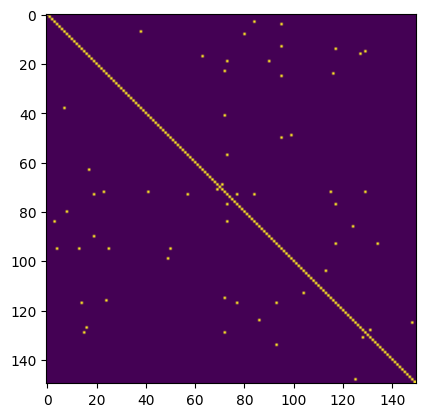

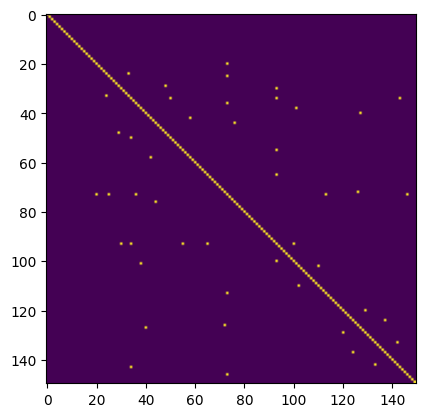

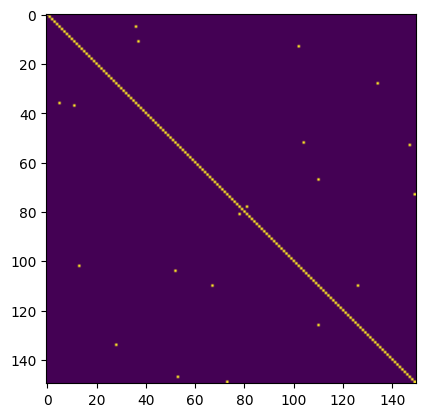

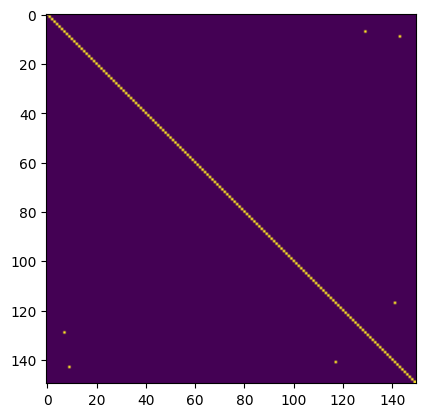

In [180]:
print(scan_series.ttcf_data)
for i in range(len(scan_series.ttcf_data.pixel_in_ring)):
    plt.figure()
    plt.imshow(scan_series.ttcf_data.ttcfs[i],vmin=1,vmax=1.17)
    plt.show

# Visualization

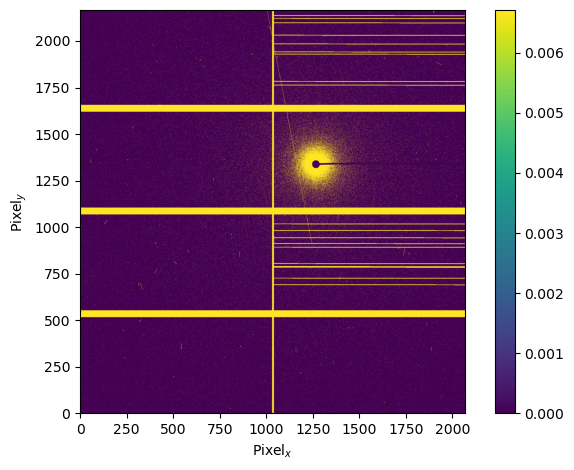

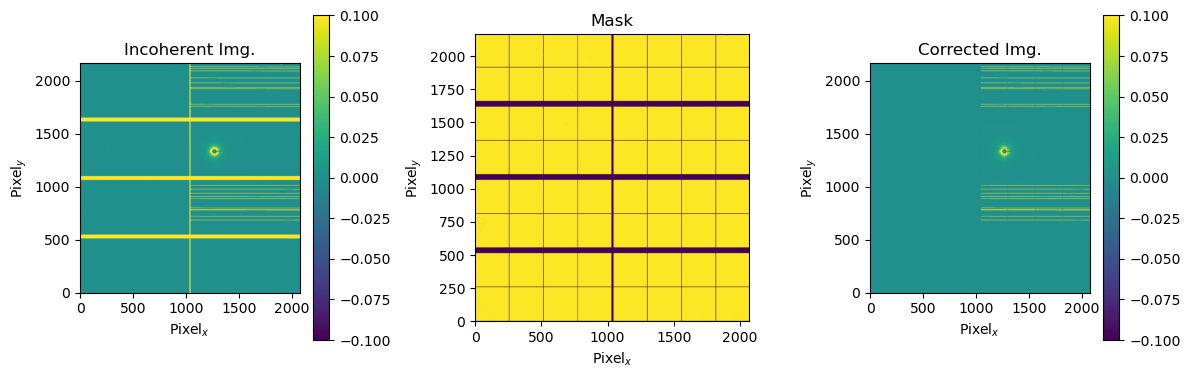

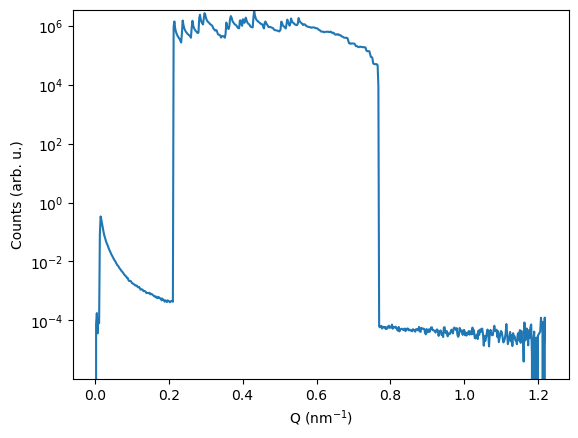

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x000001B8196A7D80> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1400x400 with 4 Axes>

In [31]:
# incoherent images (2 options)
plotting.show_incoherent_img(incoherent_img)
plotting.show_incoherent_img(incoherent_img, mask=mask, v_limits='auto')
# SAXS curves 
plotting.show_SAXS_curve(SAXS_Q, SAXS_IofQ) # converts automatically to nm-1
# evolution/degradation
plotting.show_evolution_plots(evo_SAXS_Q*1e-9, evo_SAXS_IofQ)
plotting.show_evolution_plots(frame_resolved_SAXS_Q*1e-9, frame_resolved_SAXS_IofQ, norm_reference_idx=0)
# ttcf
plotting.show_single_ttcf(ttc_per_q_partition[9,:,:], v_limits='auto')
plotting.show_all_ttcf(ttc_per_q_partition, v_limits='auto')
# g2
plotting.show_single_g2(times_multitau, g2multitau_per_q_partition[9,:],g2error=g2errormultitau_per_q_partition[9,:] ,y_limits='auto')
plotting.show_all_g2s(times_multitau, g2multitau_per_q_partition[7:12,:],g2errors=g2errormultitau_per_q_partition[7:12,:] ,y_limits=[1,1.07])
# q_partitions
detector.q_partitions.show_partitions2D(incoherent_img=incoherent_img_cor)
detector.q_rings.show_q_rings(SAXS_Q, SAXS_IofQ)